<img src='./Images/Telecommunication.webp' style='width: 100%; height: 400px; object-fit: cover;' />

---
<h1 align='center'>
SYRIATEL CHURN ANALYSIS
</h1>

> **Author**: Ngundo Muithya

> **Email**: ngundolarrymuithya@gmail.com

---

<h2 align='center'>
1. INTRODUCTION
</h2>

### Overview

SyriaTel is a leading Syrian mobile telecommunication company established in the year 2000, headquartered in Damascus, providing GSM and LTE services

SyriaTel is interested in predicting whether a customer will churn (stop working with the company) or not. It does this by keeping track of customer information on a number of attributes such as number of calls made, area code and various other metrics.

I have been tasked with creating a predictive model that will help determine if a customer will churn or not, given this customer information. The model should perform better than just random guessing (50/50).

I will do this by using the publicly available SyriaTel customer information (stored [here](./Data/syriatel_data.csv)) on churning to create two models: a **logistic regression model** and a **decision tree** and use model evaluation to determine which is better at predicting whether or not a customer will churn.

### Business Understanding

The company wants to be able to reliably predict whether a customer will churn using information about that customer such as number of calls made, whether or not they have a voice mail plan etc.

The business objectives are:
* Create a model that reliably predicts whether or not a customer will churn
* Identify the attributes that are most likely to cause churning
* Develop recommendations on how to limit churning

I will focus on two types of classifiers: **logistic regression models** and **decision trees**

---

<h2 align='center'>
2. DATA UNDERSTANDING
</h2>

I will use the publicly available data on churning provided by SyriaTel [here](./Data/syriatel_data.csv)

It contains various information about customers, including whether or not they will churn.

The columns include:

### Columns of Interest
* `state`: The US state where the customer resides (represented by a 2-letter abbreviation, e.g., KS for Kansas, OH for Ohio).

* `account length`: The number of days the customer has had an active account with the company.

* `international plan`: A binary feature (yes or no) indicating whether the customer pays for an international calling plan.

* `voice mail plan`: A binary feature (yes or no) indicating whether the customer pays for a voicemail plan.

* `total [time] minutes`: The total number of minutes the customer spent on calls during that specific time (day, evening, night, international) period.

* `total [time] calls`: The total count of individual phone calls the customer made/received during that time period.

* `total [time] charge`: The monetary amount the telecom company billed the customer for that specific usage

* `customer service calls`: The number of times the customer has called the telecom's customer service/support line. High numbers here are often a strong indicator of customer frustration.

* `area code`: The 3-digit area code of the customer's phone number

* `number vmail messages`: The number of voicemail messages the customer currently has. (If they don't have a voicemail plan, this number is usually 0)

* `churn`: This is the target variable. A boolean feature (True or False) indicating whether the customer ultimately cancelled their service ("churned") or stayed with the company.

### Other Columns

* `phone number`: The customer's 7-digit phone number. In this dataset, it essentially acts as a unique identifier for the customer.


A more descriptive definition of the columns is located [here](./Data/SyriaTel_Dataset_Feature_Dictionary.txt)

The columns of interest are the columns that hold information pertinent to helping me explain why a customer might churn and the `churn` column itself.

Other columns (such as `phone number`) cannot be effectively used to predict whether or not a customer will churn.

### Exploratory Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv('./Data/syriatel_data.csv')

df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

`international plan` and `voice mail plan` are categorical columns that hold boolean information

`phone number` and `state` are categorical columns that hold categorical information.

`area code` is a numerical column holding categorical information.

`churn` is a boolean column with True/False values.

These will need to be transformed before I can use them to train the models. I will drop the `phone number` column because it cannot be used to predict whether a customer will churn or not.

The rest are numerical columns holding numerical data. These will only need to be scaled appropriately.

The dataset also contains 3333 entries. No column contains empty values.

In [3]:
df.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

It also contains no duplicates

### Data Cleaning

Since the dataset contains no null values, no imputation is needed.

It also contains no duplicates, so I do not need to drop duplicates.

I will transform some of the columns:

In [5]:
# Drop the useless phone number column
df = df.drop('phone number', axis=1)

# Convert boolean churn to 1 and 0
df['churn'] = df['churn'].astype(int)

# Convert 'yes'/'no' string columns to 1 and 0
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

df.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


I will one-hot encode the `state` and `area code` columns later when building the models. Now, I will visualize some of the relationships in the data.

### Visualizations

I will examine the correlation between the `churn` column and the other numeric columns.

In [6]:
# I will do it on a copy to prevent destroying the original
df_corr = df.copy()

# Drop non-numeric and irrelevant columns
df_corr_numeric = df_corr.drop(columns=['state'])

# Calculate the correlation and sort it
churn_corr = df_corr_numeric.corr()['churn'].sort_values(ascending=False)

churn_corr

churn                     1.000000
international plan        0.259852
customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
total night charge        0.035496
total night minutes       0.035493
total day calls           0.018459
account length            0.016541
total eve calls           0.009233
area code                 0.006174
total night calls         0.006141
total intl calls         -0.052844
number vmail messages    -0.089728
voice mail plan          -0.102148
Name: churn, dtype: float64

Churning is most positively correlated with `international plan`. This is a strong indication that a user with an international plan is likely to churn.

It is also strongly positively correlated with `customer service calls` indicating that a customer with a higher number of customer service calls (i.e higher frustration) is likely to churn

Churning is also most negatively correlated with `voice mail plan` which indicates that a user with a voice mail plan is likely to stay.

I will visualize the number of people with international plans who churned and didn't churn:

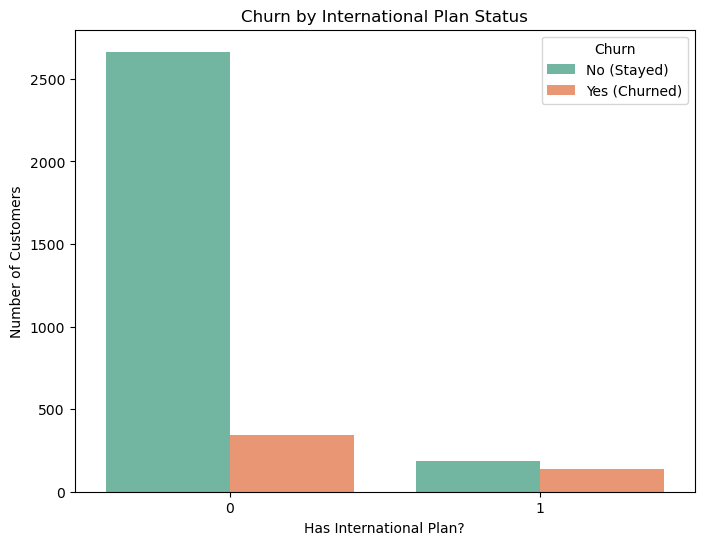

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(8, 6))

# Create a countplot
# x puts 'international plan' categories on the bottom axis
# hue splits the bars based on 'churn' status
sns.countplot(data=df, x='international plan', hue='churn', palette='Set2')

# Adding clear labels and a title
plt.title('Churn by International Plan Status')
plt.xlabel('Has International Plan?')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'])

# Display the plot
plt.show()

Customers without an international plan overwhelmingly tend to stay compared to customers with an international plan.

Visualized as percentages:

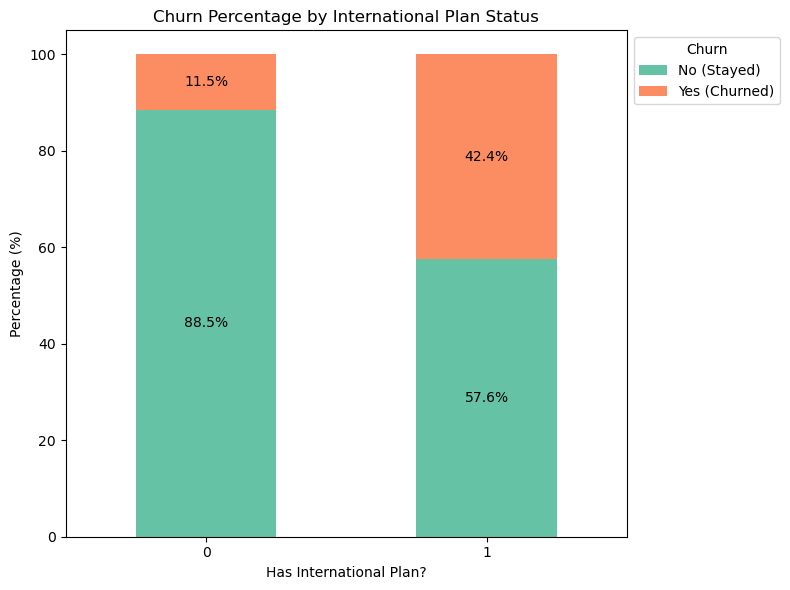

In [8]:
# Calculate the percentages
# pd.crosstab with normalize='index' converts the counts into row proportions
crosstab_percent = pd.crosstab(df['international plan'], df['churn'], normalize='index') * 100

# Create a 100% stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
crosstab_percent.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], ax=ax)

# Added formatting and labels
plt.title('Churn Percentage by International Plan Status')
plt.xlabel('Has International Plan?')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'], loc='upper left', bbox_to_anchor=(1, 1))

# Added the text numbers inside the bars for extra clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x+width/2, 
                y+height/2, 
                '{:.1f}%'.format(height), 
                horizontalalignment='center', 
                verticalalignment='center')

# Show the plot
plt.tight_layout()
plt.show()

88% of those without international plans stayed while only 57% of those with international plans stayed. 

It seems that a great indicator of whether or not a customer churns is if they have an international plan

Intuitively, this could mean that those who don't have to pay for an international plan tend to stay, while those who do pay tend to leave, perhaps, for better pay options.

I will visualize the churn distribution in voice mail plan as well:

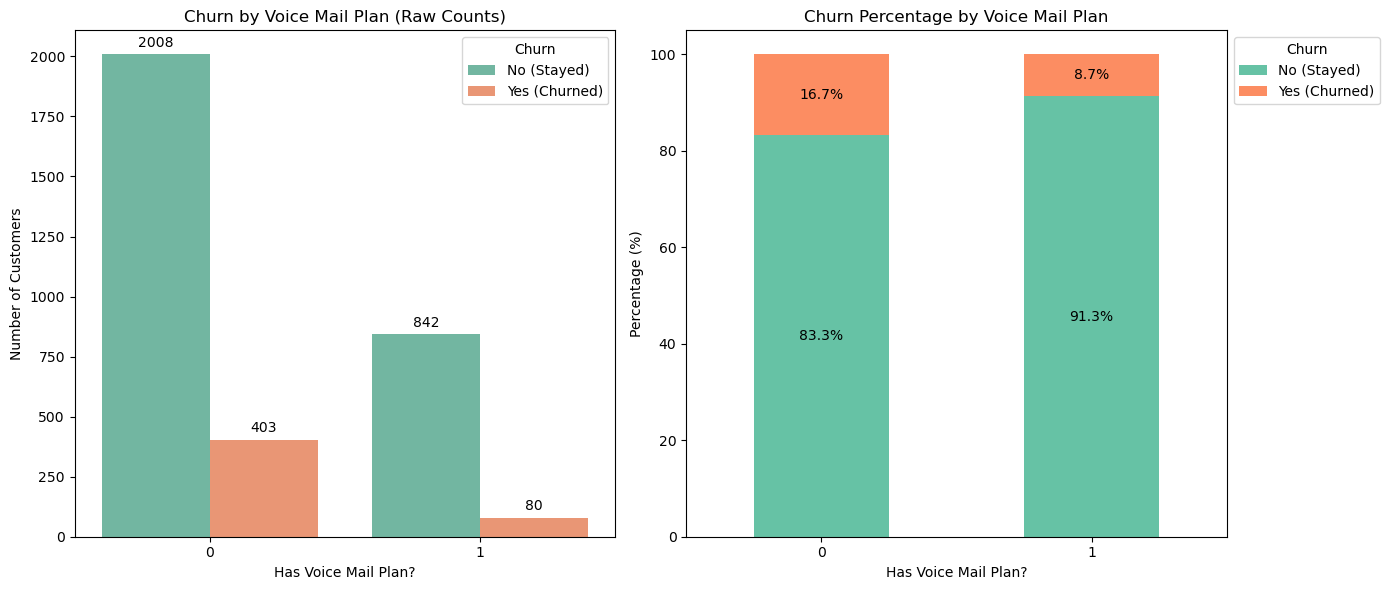

In [9]:
# Created a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# Subplot 1: Raw Counts (Left Side)
# ==========================================
sns.countplot(data=df, x='voice mail plan', hue='churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Voice Mail Plan (Raw Counts)')
axes[0].set_xlabel('Has Voice Mail Plan?')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'])

# Added text labels on top of the bars for exact counts
for p in axes[0].patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        axes[0].text(p.get_x() + p.get_width()/2., height + 20, 
                     f'{int(height)}', ha='center', va='bottom')

# ==========================================
# Subplot 2: Percentages (Right Side)
# ==========================================
# Calculated percentages across rows
crosstab_percent = pd.crosstab(df['voice mail plan'], df['churn'], normalize='index') * 100

# Plotted 100% stacked bar chart
crosstab_percent.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], ax=axes[1])
axes[1].set_title('Churn Percentage by Voice Mail Plan')
axes[1].set_xlabel('Has Voice Mail Plan?')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'], loc='upper left', bbox_to_anchor=(1, 1))

# Added text labels inside the bars for percentages
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        axes[1].text(x + width/2, y + height/2, 
                     f'{height:.1f}%', ha='center', va='center')

# Cleaned up the layout and display
plt.tight_layout()
plt.show()

A customer with a voice mail plan is less likely to churn compared to one without a voice mail plan although they are both more likely to stay.

Intuitively, this could mean that those who pay might be comfortable with the pay option offered by SyriaTel for voice mail.

---

<h2 align='center'>
3. MODEL BUILDING
</h2>

I will create two models: a **logistic regression** model and a **decision tree** model and compare the performance of the two to see which is better at predicting. I will be using the `LogisticRegression` and `DecisionTreeClassifier` classes imported from scikit-learn.

I will tune the models using different hyperparameters to ensure they generalize to the training data well and do not suffer from overfitting or underfitting.

I will be focusing on the **recall** score of the models, as the main objective is to create a model that is good at predicting churners (1) and this is measured using the **True Positive Rate** / recall.

I will start by examining if there is class imbalance in the dataset:

In [10]:
df['churn'].value_counts(), df['churn'].value_counts(normalize=True)

(churn
 0    2850
 1     483
 Name: count, dtype: int64,
 churn
 0    0.855086
 1    0.144914
 Name: proportion, dtype: float64)

Around 85% of the customers in the dataset did not churn (0). This is a big indicator that the dataset suffers from class imbalance.

If my model is to be any good at predicting churners, I will need to address this class imbalance.

### Pre-Processing

The dataset needs to be scaled and pre-processed appropriately before it can be used to train the models.

Specifically, I will do the following:

* Perform a standard train-test split

* Scale the numeric features using `MinMaxScaler`. This is done because logistic regression models in scikit-learn use l2 regularization by default. L2 regularization requires the data to be scaled.

* One-hot encode the categorical features `area code` and `state`

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Define target and features
y = df['churn']
X = df.drop('churn', axis=1)

# Do train-test split before OHE to avoid data leakage
# Use a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026, test_size=0.3)

# One hot encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
X_train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train[['state', 'area code']]),
    index = X_train.index,
    columns = ohe.get_feature_names_out()
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[['state', 'area code']]),
    index = X_test.index,
    columns = ohe.get_feature_names_out()
)
X_train_full = pd.concat(
    [X_train_ohe, X_train.drop(['state', 'area code'], axis=1)],
    axis=1
)
X_test_full = pd.concat(
    [X_test_ohe, X_test.drop(['state', 'area code'], axis=1)],
    axis=1
)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)
X_train_preprocessed = pd.DataFrame(
    X_train_scaled,
    index=X_train_full.index,
    columns=X_train_full.columns
)
X_test_preprocessed = pd.DataFrame(
    X_test_scaled,
    index=X_test_full.index,
    columns=X_test_full.columns
)

# View transformed data
X_train_preprocessed.head(), X_test_preprocessed.head()

(      state_AL  state_AR  state_AZ  state_CA  state_CO  state_CT  state_DC  \
 286        0.0       0.0       0.0       0.0       0.0       0.0       0.0   
 3202       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
 2626       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
 729        0.0       0.0       0.0       0.0       0.0       0.0       0.0   
 88         0.0       0.0       0.0       0.0       0.0       0.0       0.0   
 
       state_DE  state_FL  state_GA  ...  total eve minutes  total eve calls  \
 286        0.0       0.0       0.0  ...           0.292801         0.569620   
 3202       0.0       0.0       0.0  ...           0.770417         0.582278   
 2626       0.0       0.0       0.0  ...           0.620992         0.670886   
 729        0.0       0.0       0.0  ...           0.437387         0.626582   
 88         0.0       0.0       0.0  ...           0.278887         0.455696   
 
       total eve charge  total night minut

The dataset is now ready to be used to train and evaluate the models.

<h3 align='center'>
a) Logistic Regression
</h2>

I will start by creating a vanilla logistic regression model with default hyperparameters. This will serve as the baseline logistic model.

In [12]:
from sklearn.linear_model import LogisticRegression

# Use a model with default attributes i.e
# solver='lbfgs' and penalty='l2'
# Use a random state for reproducibility
vanilla_model = LogisticRegression(random_state=2026)

vanilla_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

I will evaluate the model on test and train data, specifically getting its recall:

In [13]:
from sklearn.metrics import recall_score

y_test_preds = vanilla_model.predict(X_test_preprocessed)
y_train_preds = vanilla_model.predict(X_train_preprocessed)

print(f"Training Recall: {recall_score(y_train, y_train_preds)}\nTesting Recall: {recall_score(y_test, y_test_preds)}")

Training Recall: 0.17647058823529413
Testing Recall: 0.225


The vanilla model has terrible recall on both the testing and training data. Specifically, there is massive underfitting. 

This might be due to the class imbalance that causes the model to not generalize well to the few churners available in the training data.

I will also view its accuracy, precision and f1 score on both training and testing data:

In [14]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

# Comparing training and testing
print(
    "Training data:\n" 
    f"   Accuracy: {accuracy_score(y_train, y_train_preds)}\n" \
    f"   Precision: {precision_score(y_train, y_train_preds)}\n" \
    f"   Recall: {recall_score(y_train, y_train_preds)}\n" \
    f"   F1 score: {f1_score(y_train, y_train_preds)}\n" \
    "Testing data:\n" \
    f"   Accuracy: {accuracy_score(y_test, y_test_preds)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds)}"
)

Training data:
   Accuracy: 0.8709815687955422
   Precision: 0.6195652173913043
   Recall: 0.17647058823529413
   F1 score: 0.2746987951807229
Testing data:
   Accuracy: 0.855
   Precision: 0.631578947368421
   Recall: 0.225
   F1 score: 0.3317972350230415


The model might seem like it has good accuracy but recall that the dataset had around 86% of the customers staying (0). Therefore, if we had a model that just blindly assumed all the customers in our dataset were going to stay it would have an accuracy of about 86%.

This vanilla model has around the same accuracy. It is no better than a model that simply guesses zeroes.

I need a better model. Specifically, a model with better **recall**. The way to do this is to address the class imbalance present in the dataset.

I will do this in two ways: **Using class weights** and **Oversampling (SMOTE)** and compare the two to see which results in a better model.

<h4 align='center'>
i) Using class weights
</h4>

I will start by building models with various class weights and plotting their recall scores.

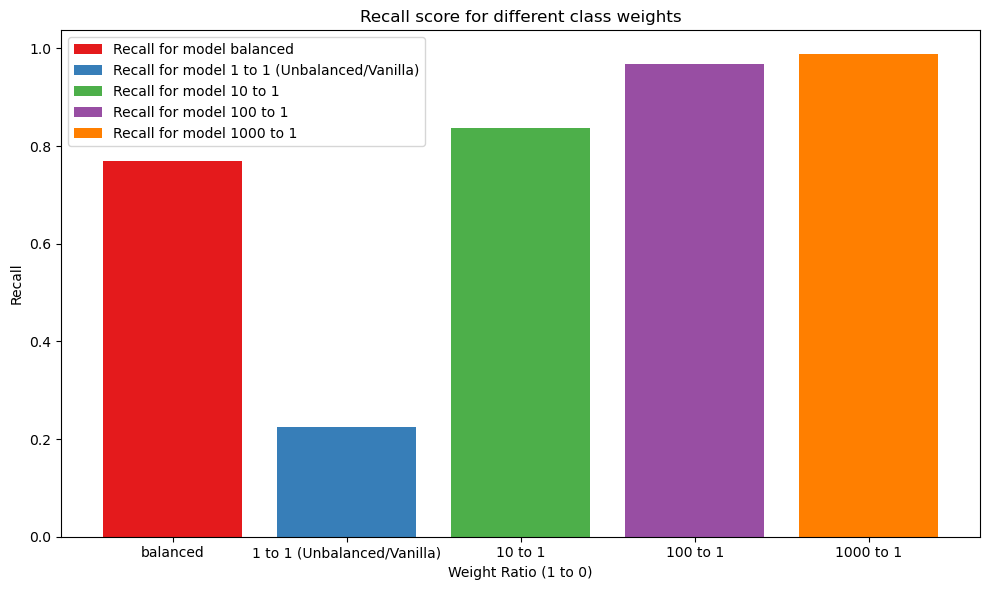

In [15]:
class_weights = ['balanced', {0: 1, 1: 1}, {0: 1, 1: 10}, {0: 1, 1: 100}, {0: 1, 1: 1000}]
names = ['balanced', '1 to 1 (Unbalanced/Vanilla)', '10 to 1', '100 to 1', '1000 to 1']
colors = sns.color_palette('Set1', n_colors=len(class_weights))
plt.figure(figsize=(10, 6))

for n, cw in enumerate(class_weights):
    # Create logreg model that uses class_weight and fit it
    logreg = LogisticRegression(class_weight=cw, random_state=2026)
    logreg.fit(X_train_preprocessed, y_train)

    # Make predictions
    y_test_preds = logreg.predict(X_test_preprocessed)

    # Calculate recall
    recall = recall_score(y_test, y_test_preds)

    # Plot
    plt.bar(
        names[n], 
        recall, 
        color=colors[n], 
        label=f"Recall for model {names[n]}"
    )

# Formatting
plt.title("Recall score for different class weights")
plt.xlabel("Weight Ratio (1 to 0)")
plt.ylabel("Recall")
plt.legend(loc='best')

# Display
plt.tight_layout()
plt.show()

The recall (True Positive Rate) increases as we increase class 1's weight. The model learns to predict the minority class better and better.

I will now plot the accuracy scores:

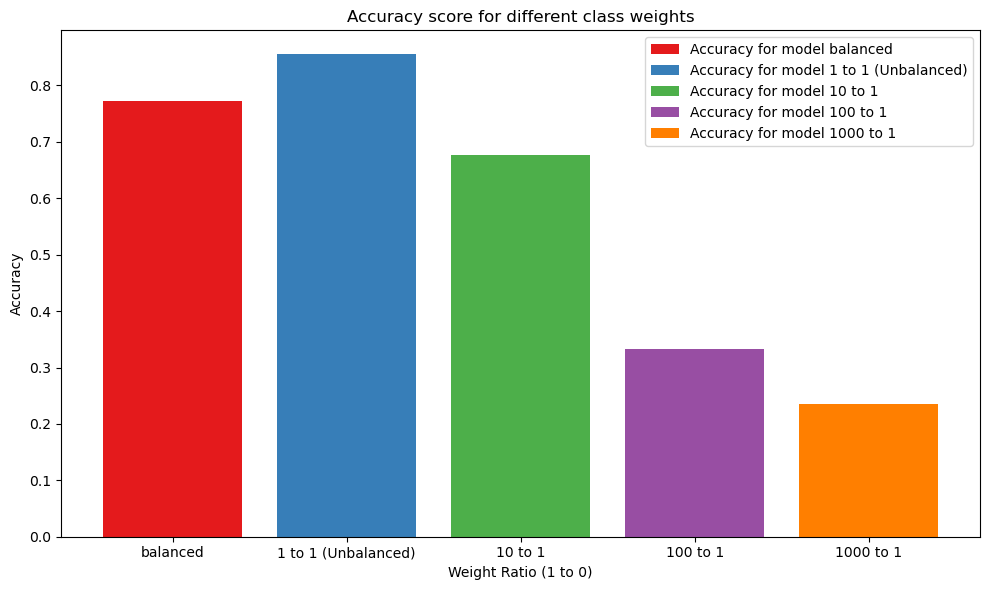

In [16]:
class_weights = ['balanced', {0: 1, 1: 1}, {0: 1, 1: 10}, {0: 1, 1: 100}, {0: 1, 1: 1000}]
names = ['balanced', '1 to 1 (Unbalanced)', '10 to 1', '100 to 1', '1000 to 1']
colors = sns.color_palette('Set1', n_colors=len(class_weights))
plt.figure(figsize=(10, 6))

for n, cw in enumerate(class_weights):
    # Create logreg model that uses class_weight and fit it
    logreg = LogisticRegression(class_weight=cw, random_state=2026)
    logreg.fit(X_train_preprocessed, y_train)

    # Make predictions
    y_test_preds = logreg.predict(X_test_preprocessed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_preds)

    # Plot
    plt.bar(
        names[n], 
        accuracy, 
        color=colors[n], 
        label=f"Accuracy for model {names[n]}"
    )

# Formatting
plt.title("Accuracy score for different class weights")
plt.xlabel("Weight Ratio (1 to 0)")
plt.ylabel("Accuracy")
plt.legend(loc='best')

# Display
plt.tight_layout()
plt.show()

The more I penalize the model for getting 1 wrong (by increasing the class 1 weight), the more 1's the model predicts and the less accurate it is on the majority class, 0, leading to a drop in the accuracy.

The weighted model with the highest accuracy is the **balanced** model.

I am being forced to trade accuracy for recall. I will plot one final metric: the ROC (Receiver Operating Characteristic) curve.

AUC for balanced: 0.8219270833333334
AUC for 1 to 1 (Unbalanced): 0.823125
AUC for 10 to 1: 0.8190922619047619
AUC for 100 to 1: 0.8054092261904763
AUC for 1000 to 1: 0.788608630952381


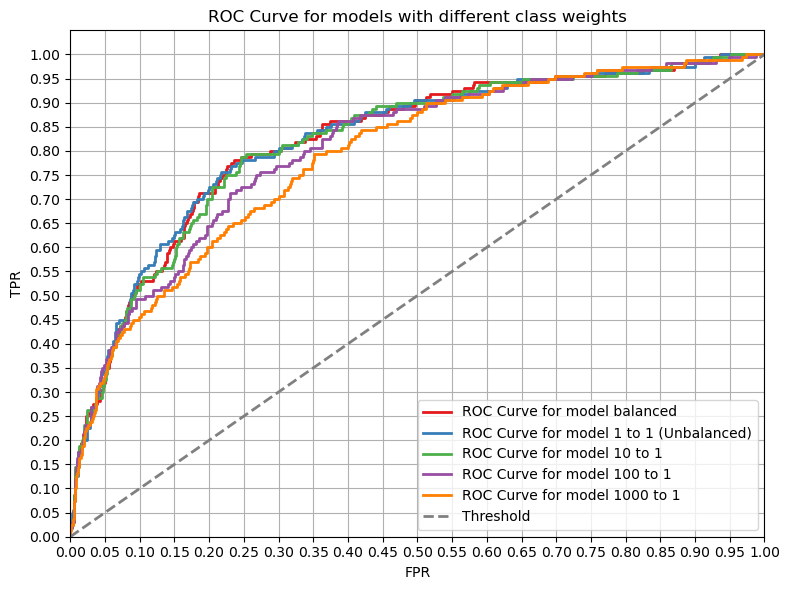

In [17]:
from sklearn.metrics import roc_curve, auc

class_weights = ['balanced', {0: 1, 1: 1}, {0: 1, 1: 10}, {0: 1, 1: 100}, {0: 1, 1: 1000}]
names = ['balanced', '1 to 1 (Unbalanced)', '10 to 1', '100 to 1', '1000 to 1']
colors = sns.color_palette('Set1', n_colors=len(class_weights))
plt.figure(figsize=(8, 6))

for n, cw in enumerate(class_weights):
    # Create logreg model that uses class_weight and fit it
    logreg = LogisticRegression(class_weight=cw, random_state=2026)
    logreg.fit(X_train_preprocessed, y_train)

    # Get confidence scores
    y_test_scores = logreg.decision_function(X_test_preprocessed)

    # Calculate roc
    fpr, tpr, thresholds = roc_curve(y_test, y_test_scores)
    print(f"AUC for {names[n]}: {auc(fpr, tpr)}")

    # Plot
    plt.plot(
        fpr, 
        tpr, 
        color=colors[n],
        lw=2, 
        label=f"ROC Curve for model {names[n]}"
    )

# Add reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', lw=2, label='Threshold')

# Formatting
plt.grid(True)
plt.xticks([i/20 for i in range(21)])
plt.yticks([i/20 for i in range(21)])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve for models with different class weights")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='best')


# Display
plt.tight_layout()
plt.show()

The AUC tends to decrease as the minority class (1) weight increases.

Of the weighted models, the best seems to be the model with a **balanced** class weight. I will compare it with the baseline vanilla model I had previously:

In [18]:
from sklearn.metrics import roc_auc_score

# Building the balanced model
balanced_model = LogisticRegression(random_state=2026, class_weight='balanced')
balanced_model.fit(X_train_preprocessed, y_train)

# Generate predictions and probabilities
y_test_preds_vanilla = vanilla_model.predict(X_test_preprocessed)
y_test_preds_balanced = balanced_model.predict(X_test_preprocessed)
y_test_probs_vanilla = vanilla_model.predict_proba(X_test_preprocessed)[:, 1]
y_test_probs_balanced = balanced_model.predict_proba(X_test_preprocessed)[:, 1]

# Comparing the two
print(
    "Vanilla (baseline) Model:\n" 
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_vanilla)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_vanilla)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_vanilla)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_vanilla)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_vanilla)}\n" \
    "Balanced Model:\n" \
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_balanced)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_balanced)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_balanced)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_balanced)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_balanced)}"
)

Vanilla (baseline) Model:
   Accuracy: 0.855
   Precision: 0.631578947368421
   Recall: 0.225
   F1 score: 0.3317972350230415
   AUC score: 0.823125
Balanced Model:
   Accuracy: 0.773
   Precision: 0.3929712460063898
   Recall: 0.76875
   F1 score: 0.5200845665961945
   AUC score: 0.8219270833333334


The model with a balanced class weight has poor accuracy and precision compared to the vanilla model. This is because it is predicting a lot more false positives compared to the vanilla model.

It makes up for this with a higher recall and f1 score.

Since **recall** is the metric I care about most, I will pick the **balanced** model.

I will record the balanced model as the best weighted model:

In [19]:
best_weighted_model = LogisticRegression(random_state=2026, class_weight='balanced')
best_weighted_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

<h4 align='center'>
ii) Using SMOTE
</h4>

In this section, I will SMOTE to oversample the minority class and train a model using the oversampled training data.

In [20]:
from imblearn.over_sampling import SMOTE

# Create a SMOTE() object with default sampling strategy
smote_obj = SMOTE()

X_train_smote, y_train_smote = smote_obj.fit_resample(X_train_preprocessed, y_train)

# View the counts. They should be equal now
y_train_smote.value_counts(), y_train.value_counts()

(churn
 0    2010
 1    2010
 Name: count, dtype: int64,
 churn
 0    2010
 1     323
 Name: count, dtype: int64)

I will now train a logistic regression model using this oversampled data:

In [21]:
oversampled_log_reg = LogisticRegression(random_state=2026)

oversampled_log_reg.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

I will evaluate the model against the best weighted model:

In [22]:
weighted_y_test_preds = best_weighted_model.predict(X_test_preprocessed)
weighted_y_test_probs = best_weighted_model.predict_proba(X_test_preprocessed)[:, 1]
oversampled_y_test_preds = oversampled_log_reg.predict(X_test_preprocessed)
oversampled_y_test_probs = oversampled_log_reg.predict_proba(X_test_preprocessed)[:, 1]


print(
    "Best Weighted Model:\n" 
    f"   Accuracy: {accuracy_score(y_test, weighted_y_test_preds)}\n" \
    f"   Precision: {precision_score(y_test, weighted_y_test_preds)}\n" \
    f"   Recall: {recall_score(y_test, weighted_y_test_preds)}\n" \
    f"   F1 score: {f1_score(y_test, weighted_y_test_preds)}\n" \
    f"   AUC score: {roc_auc_score(y_test, weighted_y_test_probs)}\n" \
    "Oversampled Model:\n" \
    f"   Accuracy: {accuracy_score(y_test, oversampled_y_test_preds)}\n" \
    f"   Precision: {precision_score(y_test, oversampled_y_test_preds)}\n" \
    f"   Recall: {recall_score(y_test, oversampled_y_test_preds)}\n" \
    f"   F1 score: {f1_score(y_test, oversampled_y_test_preds)}\n" \
    f"   AUC score: {roc_auc_score(y_test, oversampled_y_test_probs)}"
)

Best Weighted Model:
   Accuracy: 0.773
   Precision: 0.3929712460063898
   Recall: 0.76875
   F1 score: 0.5200845665961945
   AUC score: 0.8219270833333334
Oversampled Model:
   Accuracy: 0.766
   Precision: 0.37748344370860926
   Recall: 0.7125
   F1 score: 0.4935064935064935
   AUC score: 0.8072916666666669


I will visualize this comparison:

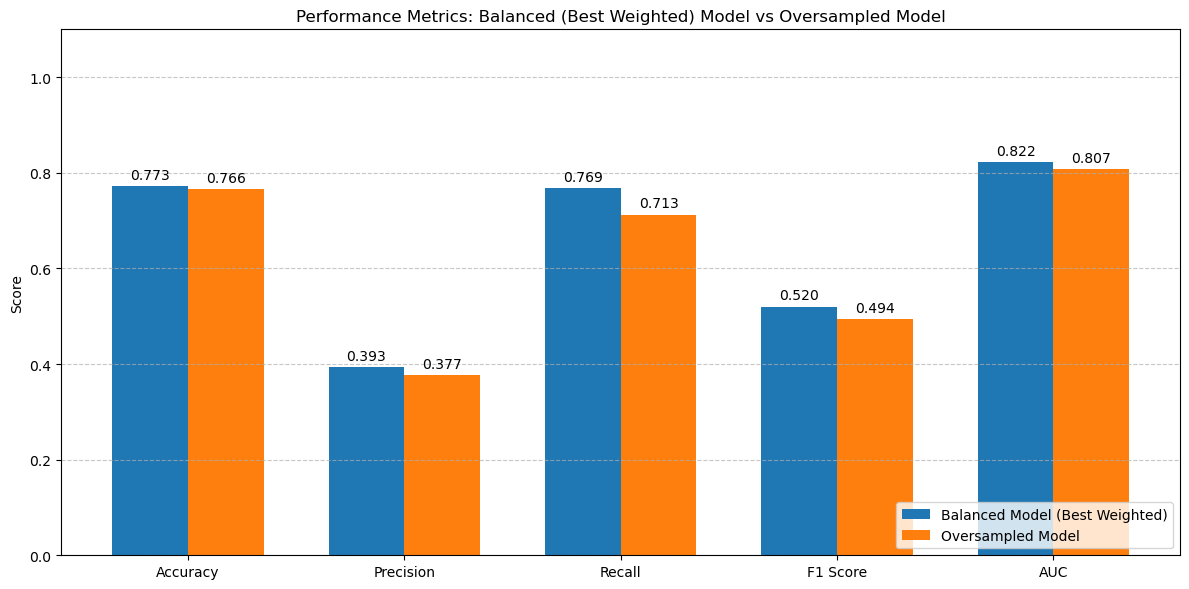

In [23]:
import numpy as np

# 1. Added AUC to our list of labels
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']

# 2. Calculated all 5 scores for the Balanced Model
balanced_scores = [
    accuracy_score(y_test, weighted_y_test_preds),
    precision_score(y_test, weighted_y_test_preds),
    recall_score(y_test, weighted_y_test_preds),
    f1_score(y_test, weighted_y_test_preds),
    roc_auc_score(y_test, weighted_y_test_probs)
]

# 3. Calculated all 5 scores for the Oversampled Model
oversampled_scores = [
    accuracy_score(y_test, oversampled_y_test_preds),
    precision_score(y_test, oversampled_y_test_preds),
    recall_score(y_test, oversampled_y_test_preds),
    f1_score(y_test, oversampled_y_test_preds),
    roc_auc_score(y_test, oversampled_y_test_probs)
]

# 4. Packaged the data into a dictionary
data = {
    'Balanced Model (Best Weighted)': balanced_scores,
    'Oversampled Model': oversampled_scores
}

# 5. Set up the figure and bar positions
x = np.arange(len(metrics))  # The label locations: [0, 1, 2, 3, 4]
width = 0.35                 # The width of the bars
multiplier = 0               # Counter for our offset

fig, ax = plt.subplots(figsize=(12, 6))

# 6. Looped through the data to plot the grouped bars
for model_name, scores in data.items():
    offset = width * multiplier
    
    # Plotted the bars
    rects = ax.bar(x + offset, scores, width, label=model_name)
    
    # Added text labels on top of the bars
    ax.bar_label(rects, fmt='%.3f', padding=3)
    
    multiplier += 1

# 7. Added formatting, titles, and labels
ax.set_ylabel('Score')
ax.set_title('Performance Metrics: Balanced (Best Weighted) Model vs Oversampled Model')
ax.set_xticks(x + width / 2, metrics)
ax.set_ylim([0, 1.1]) # Gave some extra room at the top for the labels
ax.legend(loc='lower right') 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The two models have almost similar metrics but the balanced model is better in every metric.

I shall use the balanced model as the **best logistic regression model**.

In [24]:
best_logistic_model = LogisticRegression(random_state=2026, class_weight='balanced')

best_logistic_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

<h3 align='center'>
b) Decision Tree
</h3>

I will start by training a **vanilla decision tree model** that will serve as the baseline. It will be trained on the preprocessed training data using default hyperparameters.

I will then do **hyperparameter tuning and pruning** to see if I can improve the performance.

<h4 align='center'>
i) Building the vanilla tree model
</h4>

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Added a random state for reproducibility
vanilla_decision_tree = DecisionTreeClassifier(random_state=2026)

# Train tree
vanilla_decision_tree.fit(X_train_preprocessed, y_train)

# Make predictions
y_test_preds_vanilla = vanilla_decision_tree.predict(X_test_preprocessed)

# Get and print scores
y_test_probs_vanilla = vanilla_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
print( 
    f"Accuracy: {accuracy_score(y_test, y_test_preds_vanilla)}\n" \
    f"Precision: {precision_score(y_test, y_test_preds_vanilla)}\n" \
    f"Recall: {recall_score(y_test, y_test_preds_vanilla)}\n" \
    f"F1 score: {f1_score(y_test, y_test_preds_vanilla)}\n" \
    f"AUC score: {roc_auc_score(y_test, y_test_probs_vanilla)}"
)

Accuracy: 0.913
Precision: 0.7295597484276729
Recall: 0.725
F1 score: 0.7272727272727273
AUC score: 0.8369047619047618


Already, the vanilla decision tree is showing better metrics compared to the best logistic model. This is a sign that a decision tree is probably the better model to use. 

I will try to improve the decision tree's recall performance using **hyperparameter tuning and pruning**

<h4 align='center'>
ii) Hyperparameter Tuning and Pruning
</h4>

The vanilla model did not account for the **class imbalance** present in the training data. I will set the `class_weight` hyperparameter to **balanced** to account for this and, hopefully, this improves the performance of the model.

In [26]:
# Added a random state for reproducibility
balanced_decision_tree = DecisionTreeClassifier(random_state=2026, class_weight='balanced')

# Train tree
balanced_decision_tree.fit(X_train_preprocessed, y_train)

# Make predictions
y_test_preds = balanced_decision_tree.predict(X_test_preprocessed)

# Get and print scores
y_test_probs = balanced_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
print(
    "Vanilla Model:\n" \
    f"  Accuracy: {accuracy_score(y_test, y_test_preds_vanilla)}\n" \
    f"  Precision: {precision_score(y_test, y_test_preds_vanilla)}\n" \
    f"  Recall: {recall_score(y_test, y_test_preds_vanilla)}\n" \
    f"  F1 score: {f1_score(y_test, y_test_preds_vanilla)}\n" \
    f"  AUC score: {roc_auc_score(y_test, y_test_probs_vanilla)}\n"
)
print(
    "Balanced Model:\n" \
    f"  Accuracy: {accuracy_score(y_test, y_test_preds)}\n" \
    f"  Precision: {precision_score(y_test, y_test_preds)}\n" \
    f"  Recall: {recall_score(y_test, y_test_preds)}\n" \
    f"  F1 score: {f1_score(y_test, y_test_preds)}\n" \
    f"  AUC score: {roc_auc_score(y_test, y_test_probs)}"
)

Vanilla Model:
  Accuracy: 0.913
  Precision: 0.7295597484276729
  Recall: 0.725
  F1 score: 0.7272727272727273
  AUC score: 0.8369047619047618

Balanced Model:
  Accuracy: 0.89
  Precision: 0.6602564102564102
  Recall: 0.64375
  F1 score: 0.6518987341772152
  AUC score: 0.790327380952381


The scores worsened. 

This is an indication of overfitting. To confirm this, I will print the scores of the balanced model on the training data:

In [27]:
# Make predictions
y_train_preds = balanced_decision_tree.predict(X_train_preprocessed)

# Get and print scores
y_train_probs = balanced_decision_tree.predict_proba(X_train_preprocessed)[:, 1]
print( 
    f"Accuracy: {accuracy_score(y_train, y_train_preds)}\n" \
    f"Precision: {precision_score(y_train, y_train_preds)}\n" \
    f"Recall: {recall_score(y_train, y_train_preds)}\n" \
    f"F1 score: {f1_score(y_train, y_train_preds)}\n" \
    f"AUC score: {roc_auc_score(y_train, y_train_probs)}"
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0
AUC score: 1.0


The decision tree got a perfect score on the training data. This is because it was allowed to run until it classified all of the churners and customers who stayed correctly.

I will need to limit the depth of the tree if I am to combat this overfitting.

I will decrease the `max_depth` and increase the `min_samples_leaf` to stop the tree from growing too deep and overfitting to the training data:

In [28]:
# Added a random state for reproducibility
balanced_decision_tree = DecisionTreeClassifier(
    random_state=2026, 
    class_weight='balanced', 
    max_depth=5, # Stops the tree from growing too deep
    min_samples_leaf=10 # Forces leaves to have at least 10 people in them
)

# Train tree
balanced_decision_tree.fit(X_train_preprocessed, y_train)

# Make predictions
y_test_preds = balanced_decision_tree.predict(X_test_preprocessed)

# Get and print scores
y_test_probs = balanced_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
print( 
    f"Accuracy: {accuracy_score(y_test, y_test_preds)}\n" \
    f"Precision: {precision_score(y_test, y_test_preds)}\n" \
    f"Recall: {recall_score(y_test, y_test_preds)}\n" \
    f"F1 score: {f1_score(y_test, y_test_preds)}\n" \
    f"AUC score: {roc_auc_score(y_test, y_test_probs)}"
)

Accuracy: 0.908
Precision: 0.6847826086956522
Recall: 0.7875
F1 score: 0.7325581395348837
AUC score: 0.8716480654761906


The perfomance on the test data has improved. This shows the tree has generalized well to the training data and is no longer overfitting. The recall has improved massively as well as the AUC score.

Comparing this balanced model with overfitting reduced to the base vanilla model:

In [29]:
y_test_preds_vanilla = vanilla_decision_tree.predict(X_test_preprocessed)
y_test_probs_vanilla = vanilla_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
y_test_preds_balanced = balanced_decision_tree.predict(X_test_preprocessed)
y_test_probs_balanced = balanced_decision_tree.predict_proba(X_test_preprocessed)[:, 1]


print(
    "Vanilla Decision Tree:\n" 
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_vanilla)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_vanilla)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_vanilla)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_vanilla)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_vanilla)}\n" \
    "Balanced Decision Tree:\n" \
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_balanced)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_balanced)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_balanced)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_balanced)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_balanced)}"
)

Vanilla Decision Tree:
   Accuracy: 0.913
   Precision: 0.7295597484276729
   Recall: 0.725
   F1 score: 0.7272727272727273
   AUC score: 0.8369047619047618
Balanced Decision Tree:
   Accuracy: 0.908
   Precision: 0.6847826086956522
   Recall: 0.7875
   F1 score: 0.7325581395348837
   AUC score: 0.8716480654761906


The balanced decision tree now has a better **recall**, **f1 score** and **AUC score**, which are all the metrics I wanted to see improved.

I will now try switching the `criterion` hyperparameter from the default **gini** to **entropy** and see if that improves the model:

In [30]:
# Added a random state for reproducibility
balanced_decision_tree = DecisionTreeClassifier(
    random_state=2026, 
    class_weight='balanced', 
    max_depth=5, # Stops the tree from growing too deep
    min_samples_leaf=10, # Forces leaves to have at least 10 people in them
    criterion='entropy'
)

# Train tree
balanced_decision_tree.fit(X_train_preprocessed, y_train)

# Make predictions
y_test_preds = balanced_decision_tree.predict(X_test_preprocessed)

# Get and print scores
y_test_probs = balanced_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
print( 
    f"Accuracy: {accuracy_score(y_test, y_test_preds)}\n" \
    f"Precision: {precision_score(y_test, y_test_preds)}\n" \
    f"Recall: {recall_score(y_test, y_test_preds)}\n" \
    f"F1 score: {f1_score(y_test, y_test_preds)}\n" \
    f"AUC score: {roc_auc_score(y_test, y_test_probs)}"
)

Accuracy: 0.895
Precision: 0.6470588235294118
Recall: 0.75625
F1 score: 0.6974063400576369
AUC score: 0.8514806547619047


The performance worsened. I will stick to the default **gini criterion**

I will make one final hyperparameter adjustment. I will set the `min_samples_split` to 75 to try and further reduce overfitting and see how this affects the model:

In [31]:
# Added a random state for reproducibility
balanced_decision_tree = DecisionTreeClassifier(
    random_state=2026, 
    class_weight='balanced', 
    max_depth=5, # Stops the tree from growing too deep
    min_samples_leaf=10, # Forces leaves to have at least 10 people in them
    min_samples_split=75,
    criterion='gini'
)

# Train tree
balanced_decision_tree.fit(X_train_preprocessed, y_train)

# Make predictions
y_test_preds = balanced_decision_tree.predict(X_test_preprocessed)

# Get and print scores
y_test_probs = balanced_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
print( 
    f"Accuracy: {accuracy_score(y_test, y_test_preds)}\n" \
    f"Precision: {precision_score(y_test, y_test_preds)}\n" \
    f"Recall: {recall_score(y_test, y_test_preds)}\n" \
    f"F1 score: {f1_score(y_test, y_test_preds)}\n" \
    f"AUC score: {roc_auc_score(y_test, y_test_probs)}"
)

Accuracy: 0.906
Precision: 0.6774193548387096
Recall: 0.7875
F1 score: 0.7283236994219653
AUC score: 0.8789508928571429


Comparing this to the model with the default `min_samples_split` of 2, I get:

In [32]:
default_decision_tree = DecisionTreeClassifier(
    random_state=2026, 
    class_weight='balanced', 
    max_depth=5,
    min_samples_leaf=10
)
default_decision_tree.fit(X_train_preprocessed, y_train)

y_test_preds_default = default_decision_tree.predict(X_test_preprocessed)
y_test_probs_default = default_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
y_test_preds_75 = balanced_decision_tree.predict(X_test_preprocessed)
y_test_probs_75 = balanced_decision_tree.predict_proba(X_test_preprocessed)[:, 1]

print(
    "Decision Tree with 2 min_samples_split:\n" 
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_default)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_default)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_default)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_default)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_default)}\n" \
    "Decision Tree with 75 min_samples_split:\n" \
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_75)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_75)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_75)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_75)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_75)}"
)

Decision Tree with 2 min_samples_split:
   Accuracy: 0.908
   Precision: 0.6847826086956522
   Recall: 0.7875
   F1 score: 0.7325581395348837
   AUC score: 0.8716480654761906
Decision Tree with 75 min_samples_split:
   Accuracy: 0.906
   Precision: 0.6774193548387096
   Recall: 0.7875
   F1 score: 0.7283236994219653
   AUC score: 0.8789508928571429


Their performances are nearly identical (both did very well), however, the decision tree with 2 min_samples_split has marginally better scores in **everything** apart from **AUC score**. They have similar **recall**.

I will visualize the performance of decision trees with a `criterion` of **gini** and `class_weight` of **balanced** (as those are the best values for those hyperparameters) and varying `max_depth`, `min_samples_leaf` and `min_samples_split` to get the combination of these hyperparameters that results in the best metrics:

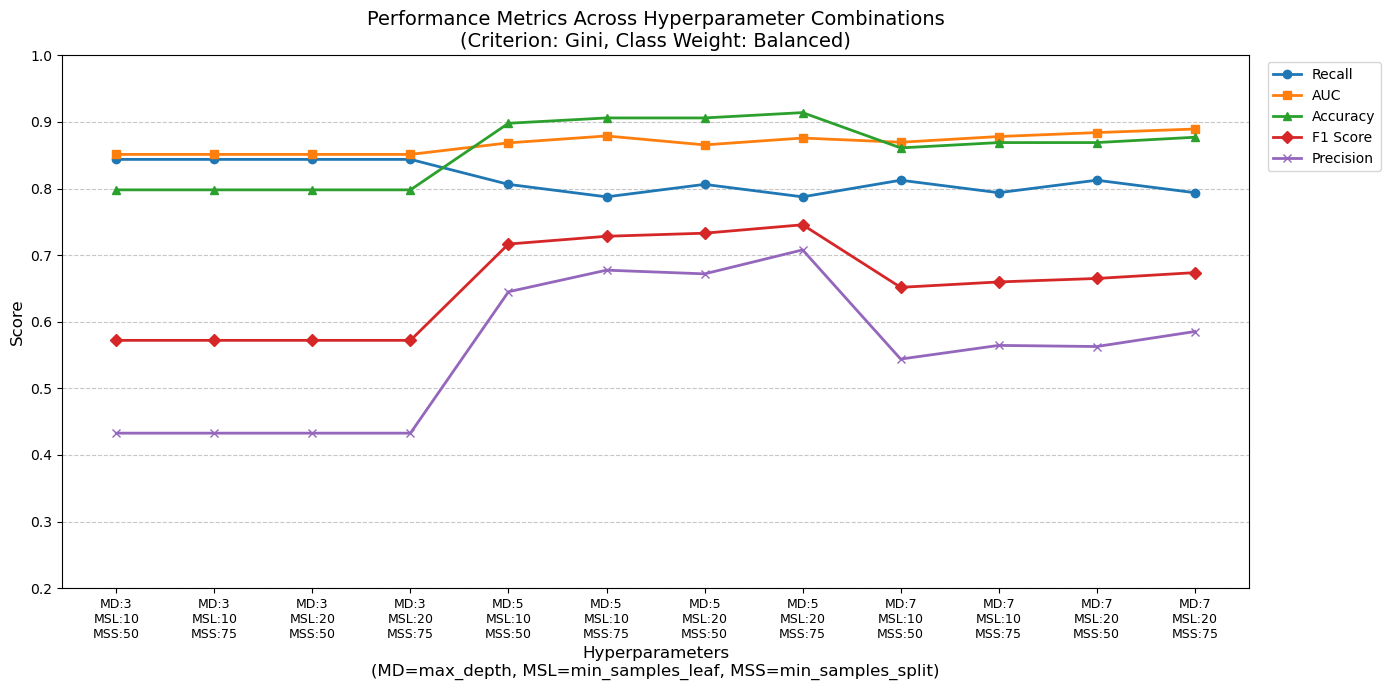

In [33]:
import itertools

# 1. Defined the hyperparameters I want to test
max_depth_opts = [3, 5, 7]
min_samples_leaf_opts = [10, 20]
min_samples_split_opts = [50, 75]

# Use itertools to generate every possible combination of the above lists
combinations = list(itertools.product(max_depth_opts, min_samples_leaf_opts, min_samples_split_opts))

# 2. Set up dictionaries to store the calculated scores for the plot
results = {
    'Labels': [], 'Accuracy': [], 'Precision': [], 
    'Recall': [], 'F1 Score': [], 'AUC': []
}

# 3. Loop through every hyperparameter combination
for md, msl, mss in combinations:
    # Create a clean label for the X-axis of the plot
    label = f"MD:{md}\nMSL:{msl}\nMSS:{mss}"
    results['Labels'].append(label)
    
    # Instantiated and trained the model with the current loop's hyperparams
    dt = DecisionTreeClassifier(
        criterion='gini',
        class_weight='balanced',
        max_depth=md,
        min_samples_leaf=msl,
        min_samples_split=mss,
        random_state=2026
    )
    dt.fit(X_train_preprocessed, y_train)
    
    # Predict classes and probabilities
    y_pred = dt.predict(X_test_preprocessed)
    y_prob = dt.predict_proba(X_test_preprocessed)[:, 1]
    
    # Store the metrics
    results['Accuracy'].append(accuracy_score(y_test, y_pred))
    results['Precision'].append(precision_score(y_test, y_pred))
    results['Recall'].append(recall_score(y_test, y_pred))
    results['F1 Score'].append(f1_score(y_test, y_pred))
    results['AUC'].append(roc_auc_score(y_test, y_prob))

# 4. Create the plot
plt.figure(figsize=(14, 7))

x = np.arange(len(combinations))

# Plot a line for each metric so we can see how they move together
plt.plot(x, results['Recall'], marker='o', label='Recall', linewidth=2)
plt.plot(x, results['AUC'], marker='s', label='AUC', linewidth=2)
plt.plot(x, results['Accuracy'], marker='^', label='Accuracy', linewidth=2)
plt.plot(x, results['F1 Score'], marker='D', label='F1 Score', linewidth=2)
plt.plot(x, results['Precision'], marker='x', label='Precision', linewidth=2)

# 5. Format the chart to make it extremely readable
plt.title('Performance Metrics Across Hyperparameter Combinations\n(Criterion: Gini, Class Weight: Balanced)', fontsize=14)
plt.xlabel('Hyperparameters\n(MD=max_depth, MSL=min_samples_leaf, MSS=min_samples_split)', fontsize=12)
plt.ylabel('Score', fontsize=12)

# Apply the custom combination text to the x-axis ticks
plt.xticks(x, results['Labels'], fontsize=9)
plt.ylim(0.2, 1.0) # Set the Y-axis range
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Move the legend outside the chart area so it doesn't block the lines
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

The best combination is:

In [34]:
# 1. Convert our existing results dictionary into a Pandas DataFrame
results_df = pd.DataFrame(results)

# 2. Create a new column called 'Total_Score'
# We tell pandas to look at our 5 metric columns and sum them up row by row (axis=1)
results_df['Total_Score'] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']].sum(axis=1)

# 3. Sort the DataFrame from highest Total Score to lowest
sorted_results = results_df.sort_values(by='Total_Score', ascending=False)

# 4. Extract the absolute best row (index 0 after sorting)
best_combo = sorted_results.iloc[0]

print("🏆 THE WINNING HYPERPARAMETER COMBINATION 🏆")
print("-" * 40)
print(f"Hyperparameters:\n{best_combo['Labels']}\n")
print(f"Total Combined Score: {best_combo['Total_Score']:.3f}\n")
print("Individual Breakdown:")
print(f"  Accuracy:  {best_combo['Accuracy']:.3f}")
print(f"  Precision: {best_combo['Precision']:.3f}")
print(f"  Recall:    {best_combo['Recall']:.3f}")
print(f"  F1 Score:  {best_combo['F1 Score']:.3f}")
print(f"  AUC:       {best_combo['AUC']:.3f}")

🏆 THE WINNING HYPERPARAMETER COMBINATION 🏆
----------------------------------------
Hyperparameters:
MD:5
MSL:20
MSS:75

Total Combined Score: 4.031

Individual Breakdown:
  Accuracy:  0.914
  Precision: 0.708
  Recall:    0.787
  F1 Score:  0.746
  AUC:       0.876


The hyperparameter combination that results in the best possible scores are:

* `criterion`:  **gini**
* `class_weight`:  **balanced**
* `max_depth`: **5**
* `min_samples_leaf`: **20**
* `min_samples_split`: **75**

Comparing a decision tree built using these hyperparameters with the vanilla decision tree model, I get:

In [35]:
hyperparam_decision_tree = DecisionTreeClassifier(
    random_state=2026,
    criterion='gini',
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=75
)
hyperparam_decision_tree.fit(X_train_preprocessed, y_train)

y_test_preds_hyperparam = hyperparam_decision_tree.predict(X_test_preprocessed)
y_test_probs_hyperparam = hyperparam_decision_tree.predict_proba(X_test_preprocessed)[:, 1]
y_test_preds_vanilla = vanilla_decision_tree.predict(X_test_preprocessed)
y_test_probs_vanilla = vanilla_decision_tree.predict_proba(X_test_preprocessed)[:, 1]

print(
    "Decision Tree with hyperparameter tuning:\n" 
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_hyperparam)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_hyperparam)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_hyperparam)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_hyperparam)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_hyperparam)}\n" \
    "Vanilla Decision Tree:\n" \
    f"   Accuracy: {accuracy_score(y_test, y_test_preds_vanilla)}\n" \
    f"   Precision: {precision_score(y_test, y_test_preds_vanilla)}\n" \
    f"   Recall: {recall_score(y_test, y_test_preds_vanilla)}\n" \
    f"   F1 score: {f1_score(y_test, y_test_preds_vanilla)}\n" \
    f"   AUC score: {roc_auc_score(y_test, y_test_probs_vanilla)}"
)

Decision Tree with hyperparameter tuning:
   Accuracy: 0.914
   Precision: 0.7078651685393258
   Recall: 0.7875
   F1 score: 0.7455621301775148
   AUC score: 0.8758296130952381
Vanilla Decision Tree:
   Accuracy: 0.913
   Precision: 0.7295597484276729
   Recall: 0.725
   F1 score: 0.7272727272727273
   AUC score: 0.8369047619047618


The decision tree with hyperparameters is better than the vanilla model in **all** of the metrics but **precision**.

I will select **the decision tree with those hyperparameters** as the **best decision tree model**.

In [36]:
best_decision_tree = DecisionTreeClassifier(
    random_state=2026,
    criterion='gini',
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=75
)
best_decision_tree.fit(X_train_preprocessed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",75
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

---

<h2 align='center'>
4. MODEL SELECTION
</h2>

I have the **best logistic regression model** and the **best decision tree model**

I will compare these two directly to see which has better metrics.

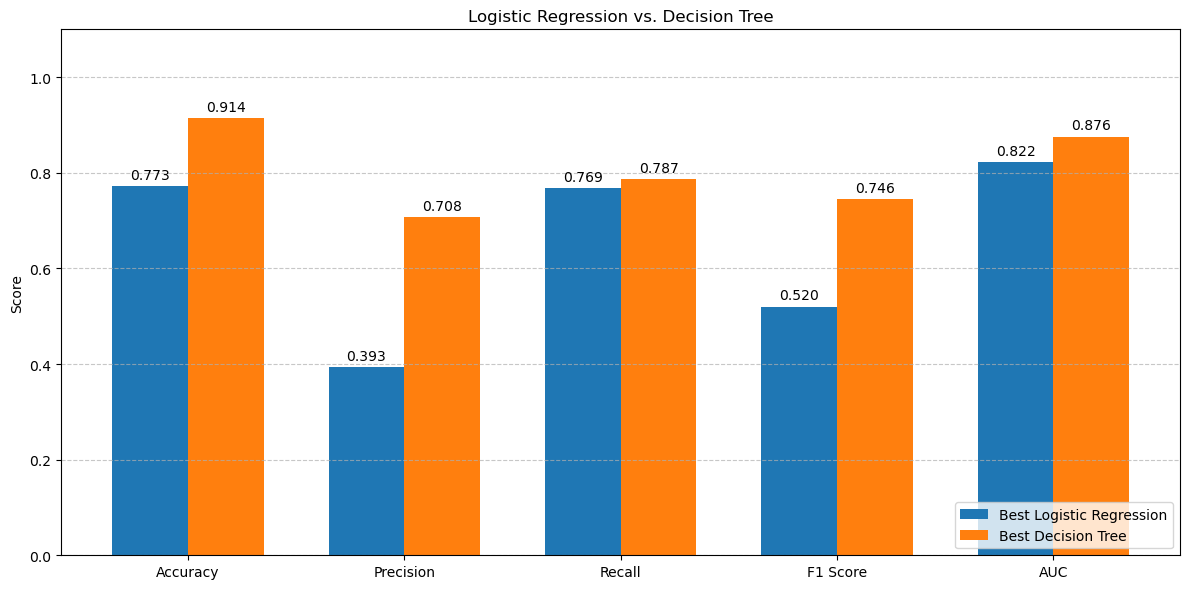

In [37]:
# 1. Get predictions (for Acc, Prec, Rec, F1) and probabilities (for AUC)
# --- Logistic Regression ---
logreg_preds = best_logistic_model.predict(X_test_preprocessed)
logreg_probs = best_logistic_model.predict_proba(X_test_preprocessed)[:, 1]

# --- Decision Tree ---
tree_preds = best_decision_tree.predict(X_test_preprocessed)
tree_probs = best_decision_tree.predict_proba(X_test_preprocessed)[:, 1]

# 2. Set up the labels
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']

# 3. Calculate all 5 scores for Logistic Regression
logreg_scores = [
    accuracy_score(y_test, logreg_preds),
    precision_score(y_test, logreg_preds),
    recall_score(y_test, logreg_preds),
    f1_score(y_test, logreg_preds),
    roc_auc_score(y_test, logreg_probs)
]

# 4. Calculate all 5 scores for the Decision Tree
tree_scores = [
    accuracy_score(y_test, tree_preds),
    precision_score(y_test, tree_preds),
    recall_score(y_test, tree_preds),
    f1_score(y_test, tree_preds),
    roc_auc_score(y_test, tree_probs)
]

# 5. Package the data into a dictionary for easy looping
data = {
    'Best Logistic Regression': logreg_scores,
    'Best Decision Tree': tree_scores
}

# 6. Set up the figure and bar positions
x = np.arange(len(metrics))  # The label locations: [0, 1, 2, 3, 4]
width = 0.35                 # The width of the bars
multiplier = 0               # Counter for our offset

fig, ax = plt.subplots(figsize=(12, 6))

# 7. Loop through the data to plot the grouped bars
for model_name, scores in data.items():
    offset = width * multiplier
    
    # Plot the bars for this specific model
    rects = ax.bar(x + offset, scores, width, label=model_name)
    
    # Add text labels on top of the bars formatted to 3 decimal places
    ax.bar_label(rects, fmt='%.3f', padding=3)
    
    multiplier += 1

# 8. Add formatting, titles, and labels
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs. Decision Tree')
# Center the x-tick labels perfectly between the two bars
ax.set_xticks(x + width / 2, metrics)
ax.set_ylim([0, 1.1]) # Give extra room for the labels at the top
ax.legend(loc='lower right')

# Add a subtle grid to make comparing heights easier
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The **decision tree** is the better model of the two using **all** metrics.

The **decision tree model** is the **better classifier**.

---

<h2 align='center'>
5. CONCLUSION
</h2>

The better classification model to use is the `best_decision_tree`. It has better **recall** compared to the `best_logistic_model` and performs better in all other categories.

> **NB**: This is by no means the **best model there is**, but it is a good model. Scope and time constraints have led me to not examine the wide array of different hyperparameter combinations that both models have. If I had, I probably would have found a model with better scores (although this is unlikely). More about this below in the **Next Steps** section.

---

<h2 align='center'>
6. RECOMMENDATIONS
</h2>

### a) Model Recommendation

The best model to use for prediciting is `best_decision_tree`. It provides great overall metrics and does well predicting both **those who will stay** (represented by 0, as demonstrated by its high accuracy) and **those who will churn** (1, as demonstrated by it's relatively high recall).

The decision tree model also has accuracy higher than the baseline (0.855), which means it is a better predictor than a model that just predicts zeroes.

This is not to say that the logistic model does not have its uses. It can be used in **inference** to observe the strength of the relationship between different features and the target. For feature-target relationship strength, linear regression coefficients are used:

In [38]:
max_coef = best_logistic_model.coef_.max()
min_coef = best_logistic_model.coef_.min()
coefficients = list(best_logistic_model.coef_.flatten())
columns = list(X_train_preprocessed.columns)
relationships = {}

# Create a dictionary to store the various column's with their coefficients
for n, coef in enumerate(coefficients):
    relationships[columns[n]] = coef

strongest_predictors = [(key, value) for key, value in relationships.items() if value == max_coef or value == min_coef]

strongest_predictors

[('voice mail plan', np.float64(-1.5620713973344602)),
 ('customer service calls', np.float64(4.531437553372001))]

According to the logistic model, the strongest predictors for whether or not a customer churned are **whether they had a voice mail plan** and the **number of customer service calls**, with having a voice mail plan being associated with **staying** while a higher number of customer service calls is strongly associated with the customer **leaving**.

> This is intuitive, as, if a customer calls customer service more often, it is safe to assume that they are not happy with the service and are more likely to churn.

### b) Business Recommendations

It was observed that **having a voice mail plan**, **an international plan** and **the number of customer service calls** were some of the strongest factors associated with whether or not a customer churned.

As such, here are some business recommendations:

* **Lower the price of an international plan**: It was observed that a significant number (42.4%) of those with international plans churned. This might be because of better prices being offered by competitors. It is recommended to study the pricing options being offered by companies such as **MTN Syria**, our primary competitor, and see if we might be overcharging.

* **Streamline customer service operations**: It was observed that customers with a higher number of customer service calls churned. It might be that something about the customer service experience is not to their liking. It is recommended to improve the customer service experience by doing things such as follow-ups to see if that lowers the churning rate.

* **Offer voice mail plans to more customers**: It was observed that 91.3% of those with voice mail plans stayed. It might be that the customers are extremely satisfied with the voice mail plan being offered (more data on this needs to be collected). As such, marketing of the voice mail plan should be done to get more customers using it and lower the churn rate.

---

<h2 align='center'>
7. NEXT STEPS
</h2>

* Perform **cross-validation** to see how the models perform using different training and test sets

* Play around with combinations of other hyperparameters to see if they improve performance:

    * Logistic Regression:

        * `fit_intercept`: Check to see if excluding the intercept improves the performance of the model

        * `C`: This is the inverse of regularization strength. Check to see if increasing or decreasing this value improves the performance

        * `l1_ratio`: This specifies the type of regularization applied. Ranges from 0 to 1: 0 for l2 penalty, 1 for l1 penalty and any number in between for Elastic Net penalty

        * `tol`: This is the error tolerance the model has when performing gradient descent. A lower value means the model will try to find the best parameters (i.e. overfit), while a higher value sets a larger tolerance for underfitting

        * `max_iter`: This is the number of iterations performed during gradient descent. A higher value overfits the model; a lower value underfits it.

    * Decision Tree:

        * `splitter`: Can be set to 'best' or 'random' and specifies how splitting is done

* I will also save the model for later use:

In [39]:
import joblib

# Saving (dumping) the model to a file
# The '.pkl' extension stands for "pickle", the standard Python object saving format
joblib.dump(best_decision_tree, './Model/final_decision_tree_model.pkl')

print("Model saved successfully!")

Model saved successfully!


---